# Sustainable PEFT Benchmark Notebook

This notebook follows the benchmark paper in [Sustainable_PEFT_Benchmark.md](Sustainable_PEFT_Benchmark.md): setup, configuration, synthetic Mode A generation, aggregation, Pareto scoring, and the Green PEFT decision layer.

## Ordered Workflow
1. Environment setup and project paths
2. Config bootstrap for backbones, tasks, and methods
3. Synthetic data generation
4. Aggregation and scoring
5. Green Efficiency Index and recommendations
6. Visualization and export

## Notes
This notebook now keeps only the canonical workflow.

In [ ]:
from pathlib import Path

ROOT = Path.cwd()
RESULTS_DIR = ROOT / 'results'
RAW_DIR = RESULTS_DIR / 'raw'
FIGURES_DIR = RESULTS_DIR / 'figures'
CONFIG_DIR = ROOT / 'configs'
METHODS_DIR = CONFIG_DIR / 'methods'
SRC_DIR = ROOT / 'src'

for directory in [RESULTS_DIR, RAW_DIR, FIGURES_DIR, CONFIG_DIR, METHODS_DIR, SRC_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

print(f'Workspace root: {ROOT}')
print('Required folders are ready.')

Workspace root: /content
Required folders are ready.


In [ ]:
import yaml
from pathlib import Path

config_dir = Path('configs')
method_dir = config_dir / 'methods'
config_dir.mkdir(parents=True, exist_ok=True)
method_dir.mkdir(parents=True, exist_ok=True)

backbones = {
    'tiny': {
        'model_id': 'TinyLlama/TinyLlama-1.1B-Chat-v1.0',
        'revision': 'main',
    },
    'small': {
        'model_id': 'google/gemma-2b',
        'revision': 'main',
    },
    'medium': {
        'model_id': 'google/gemma-7b',
        'revision': 'main',
    },
    'large': {
        'model_id': 'google/gemma-2-9b',
        'revision': 'main',
    },
}

tasks = {
    'classification': {
        'dataset_id': 'stanfordnlp/sst2',
        'text_field': 'sentence',
        'label_field': 'label',
        'train_size': 100,
    },
    'summarization': {
        'dataset_id': 'cnn_dailymail',
        'config_name': '3.0.0',
        'text_field': 'article',
        'summary_field': 'highlights',
        'max_source_length': 1024,
        'max_target_length': 128,
        'train_size': 50,
    },
    'instruction_following': {
        'dataset_id': 'openai/gsm8k',
        'config_name': 'main',
        'text_field': 'question',
        'label_field': 'answer',
        'max_source_length': 512,
        'max_target_length': 256,
        'train_size': 50,
    },
}

methods = {
    'full_ft': {
        'method': 'full_ft',
        'sweep': {'learning_rate': [5e-6, 1e-5]},
        'fixed': {},
    },
    'lora': {
        'method': 'lora',
        'sweep': {
            'rank': [4, 8, 16, 32],
            'alpha': [16, 32],
            'target_modules': [['q_proj', 'v_proj'], ['q_proj', 'k_proj', 'v_proj', 'o_proj']],
            'learning_rate': [1e-4, 2e-4],
        },
        'fixed': {'lora_dropout': 0.05, 'bias': 'none'},
    },
    'qlora': {
        'method': 'qlora',
        'sweep': {
            'rank': [8, 16, 32],
            'learning_rate': [1e-4, 2e-4],
        },
        'fixed': {
            'quant_type': 'nf4',
            'double_quant': True,
            'compute_dtype': 'bfloat16',
            'target_modules': ['q_proj', 'k_proj', 'v_proj', 'o_proj'],
        },
    },
    'lora_fa': {
        'method': 'lora_fa',
        'sweep': {
            'rank': [8, 16, 32],
            'learning_rate': [1e-4, 2e-4],
        },
        'fixed': {
            'freeze_matrix': 'A',
            'init_scheme': 'kaiming_uniform',
        },
    },
    'lisa': {
        'method': 'lisa',
        'sweep': {
            'layer_sample_prob': [0.25, 0.5],
            'resample_every_n_steps': [10, 50],
        },
        'fixed': {
            'always_train': ['embed_tokens', 'lm_head'],
        },
    },
}

with open(config_dir / 'backbones.yaml', 'w', encoding='utf-8') as handle:
    yaml.safe_dump({'backbones': backbones}, handle, sort_keys=False)

with open(config_dir / 'tasks.yaml', 'w', encoding='utf-8') as handle:
    yaml.safe_dump({'tasks': tasks}, handle, sort_keys=False)

for method_name, method_cfg in methods.items():
    with open(method_dir / f'{method_name}.yaml', 'w', encoding='utf-8') as handle:
        yaml.safe_dump(method_cfg, handle, sort_keys=False)

print('Benchmark configs written for backbones, tasks, and PEFT methods.')

Benchmark configs written for backbones, tasks, and PEFT methods.


In [ ]:
import json
import random
from pathlib import Path

random.seed(42)
raw_dir = Path('results/raw')
raw_dir.mkdir(parents=True, exist_ok=True)

base_results = {
    ('full_ft', 'large'): {'accuracy': 0.906, 'energy_kwh': 0.759, 'carbon_kgco2eq': 0.292, 'score_balanced': 0.300},
    ('full_ft', 'medium'): {'accuracy': 0.875, 'energy_kwh': 0.282, 'carbon_kgco2eq': 0.109, 'score_balanced': 0.300},
    ('full_ft', 'small'): {'accuracy': 0.795, 'energy_kwh': 0.042, 'carbon_kgco2eq': 0.016, 'score_balanced': 0.300},
    ('lora', 'large'): {'accuracy': 0.881, 'energy_kwh': 0.143, 'carbon_kgco2eq': 0.055, 'score_balanced': 0.682},
    ('lora', 'medium'): {'accuracy': 0.861, 'energy_kwh': 0.050, 'carbon_kgco2eq': 0.019, 'score_balanced': 0.780},
    ('lora', 'small'): {'accuracy': 0.785, 'energy_kwh': 0.019, 'carbon_kgco2eq': 0.007, 'score_balanced': 0.631},
    ('qlora', 'large'): {'accuracy': 0.873, 'energy_kwh': 0.088, 'carbon_kgco2eq': 0.034, 'score_balanced': 0.719},
    ('qlora', 'medium'): {'accuracy': 0.843, 'energy_kwh': 0.024, 'carbon_kgco2eq': 0.009, 'score_balanced': 0.759},
    ('qlora', 'small'): {'accuracy': 0.778, 'energy_kwh': 0.010, 'carbon_kgco2eq': 0.004, 'score_balanced': 0.705},
    ('lora_fa', 'large'): {'accuracy': 0.883, 'energy_kwh': 0.143, 'carbon_kgco2eq': 0.055, 'score_balanced': 0.714},
    ('lora_fa', 'medium'): {'accuracy': 0.849, 'energy_kwh': 0.047, 'carbon_kgco2eq': 0.018, 'score_balanced': 0.720},
    ('lora_fa', 'small'): {'accuracy': 0.784, 'energy_kwh': 0.017, 'carbon_kgco2eq': 0.007, 'score_balanced': 0.658},
    ('lisa', 'large'): {'accuracy': 0.870, 'energy_kwh': 0.214, 'carbon_kgco2eq': 0.082, 'score_balanced': 0.555},
    ('lisa', 'medium'): {'accuracy': 0.835, 'energy_kwh': 0.072, 'carbon_kgco2eq': 0.028, 'score_balanced': 0.560},
    ('lisa', 'small'): {'accuracy': 0.777, 'energy_kwh': 0.010, 'carbon_kgco2eq': 0.004, 'score_balanced': 0.629},
}

seeds = [13, 42, 2024]
methods = ['full_ft', 'lora', 'qlora', 'lora_fa', 'lisa']
backbones = ['small', 'medium', 'large']

for method in methods:
    for backbone in backbones:
        base = base_results[(method, backbone)]
        for seed in seeds:
            noise = (seed % 10 - 4) * 0.001
            record = {
                'run_id': f'{method}_{backbone}_classification_seed{seed}_0',
                'method': method,
                'backbone': backbone,
                'task': 'classification',
                'seed': seed,
                'performance': {
                    'accuracy': round(base['accuracy'] + noise, 4),
                },
                'efficiency': {
                    'wall_clock_seconds': round(600 * (1 + (0.02 if method == "lisa" else 0.0)), 1),
                    'peak_gpu_memory_gb': round({
                        'small': 6.0,
                        'medium': 14.0,
                        'large': 22.0,
                    }[backbone] * ({'full_ft': 1.0, 'lora': 0.7, 'qlora': 0.5, 'lora_fa': 0.65, 'lisa': 0.6}[method]), 2),
                    'trainable_param_pct': {
                        'full_ft': 1.0,
                        'lora': 0.015,
                        'qlora': 0.015,
                        'lora_fa': 0.012,
                        'lisa': 0.05,
                    }[method],
                },
                'energy': {
                    'total_kwh': round(base['energy_kwh'] * (1 + noise), 4),
                },
                'carbon': {
                    'kgco2eq': round(base['carbon_kgco2eq'] * (1 + noise), 4),
                },
                'cost_proxy_usd': round(base['energy_kwh'] * 1.2, 2),
                'sustainability': {
                    'score_balanced': base['score_balanced'],
                },
            }
            with open(raw_dir / f"{record['run_id']}.json", 'w', encoding='utf-8') as handle:
                json.dump(record, handle, indent=2)

print(f'Generated synthetic Mode A runs in {raw_dir}.')

Generated synthetic Mode A runs in results/raw.


In [ ]:
import json
from glob import glob
from pathlib import Path

import pandas as pd

records = []
for path in glob('results/raw/*.json'):
    with open(path, 'r', encoding='utf-8') as handle:
        payload = json.load(handle)
    records.append({
        'run_id': payload['run_id'],
        'method': payload['method'],
        'backbone': payload['backbone'],
        'task': payload['task'],
        'seed': payload['seed'],
        'accuracy': payload['performance']['accuracy'],
        'wall_clock_s': payload['efficiency']['wall_clock_seconds'],
        'peak_mem_gb': payload['efficiency']['peak_gpu_memory_gb'],
        'trainable_pct': payload['efficiency']['trainable_param_pct'],
        'energy_kwh': payload['energy']['total_kwh'],
        'carbon_kgco2eq': payload['carbon']['kgco2eq'],
        'cost_usd': payload['cost_proxy_usd'],
        'score_balanced': payload['sustainability']['score_balanced'],
    })

df = pd.DataFrame(records)
if df.empty:
    raise RuntimeError('No raw JSON files were found in results/raw.')

summary = df.groupby(['method', 'backbone', 'task'], as_index=False).agg(
    accuracy_mean=('accuracy', 'mean'),
    accuracy_std=('accuracy', 'std'),
    wall_clock_s_mean=('wall_clock_s', 'mean'),
    wall_clock_s_std=('wall_clock_s', 'std'),
    peak_mem_gb_mean=('peak_mem_gb', 'mean'),
    peak_mem_gb_std=('peak_mem_gb', 'std'),
    trainable_pct_mean=('trainable_pct', 'mean'),
    energy_kwh_mean=('energy_kwh', 'mean'),
    energy_kwh_std=('energy_kwh', 'std'),
    carbon_kgco2eq_mean=('carbon_kgco2eq', 'mean'),
    carbon_kgco2eq_std=('carbon_kgco2eq', 'std'),
    cost_usd_mean=('cost_usd', 'mean'),
    score_balanced_mean=('score_balanced', 'mean'),
    n_seeds=('seed', 'nunique'),
)

summary['perf_per_kwh'] = summary['accuracy_mean'] / summary['energy_kwh_mean']
summary['perf_per_carbon'] = summary['accuracy_mean'] / summary['carbon_kgco2eq_mean']

Path('results').mkdir(exist_ok=True)
df.to_csv('results/sweep_raw.csv', index=False)
summary.to_csv('results/aggregated.csv', index=False)
print('Wrote results/sweep_raw.csv and results/aggregated.csv.')
display(summary.head())

Wrote results/sweep_raw.csv and results/aggregated.csv.


,method,backbone,task,accuracy_mean,accuracy_std,wall_clock_s_mean,wall_clock_s_std,peak_mem_gb_mean,peak_mem_gb_std,trainable_pct_mean,energy_kwh_mean,energy_kwh_std,carbon_kgco2eq_mean,carbon_kgco2eq_std,cost_usd_mean,score_balanced_mean,n_seeds,perf_per_kwh,perf_per_carbon
0,full_ft,large,classification,0.905,0.001,600.0,0.0,22.0,0.0,1.00,0.758233,0.000751,0.291700,0.000300,0.91,0.300,3,1.193564,3.102503
1,full_ft,medium,classification,0.874,0.001,600.0,0.0,14.0,0.0,1.00,0.281700,0.000300,0.108900,0.000100,0.34,0.300,3,3.102591,8.025712
2,full_ft,small,classification,0.794,0.001,600.0,0.0,6.0,0.0,1.00,0.041967,0.000058,0.016000,0.000000,0.05,0.300,3,18.919778,49.625000
3,lisa,large,classification,0.869,0.001,612.0,0.0,13.2,0.0,0.05,0.213800,0.000200,0.081900,0.000100,0.26,0.555,3,4.064546,10.610501
4,lisa,medium,classification,0.834,0.001,612.0,0.0,8.4,0.0,0.05,0.071933,0.000058,0.027967,0.000058,0.09,0.560,3,11.594069,29.821216


In [ ]:
import pandas as pd

summary = pd.read_csv('results/aggregated.csv')

profiles = {
    'balanced': {'accuracy': 0.30, 'energy': 0.20, 'carbon': 0.20, 'time': 0.15, 'memory': 0.15},
    'accuracy_first': {'accuracy': 0.50, 'energy': 0.10, 'carbon': 0.10, 'time': 0.15, 'memory': 0.15},
    'carbon_constrained': {'accuracy': 0.20, 'energy': 0.25, 'carbon': 0.30, 'time': 0.15, 'memory': 0.10},
}


def normalize(series, minimize=False):
    scale = (series - series.min()) / (series.max() - series.min() + 1e-9)
    return 1 - scale if minimize else scale


def pareto_front(frame, maximize_col='accuracy_mean', minimize_col='carbon_kgco2eq_mean'):
    ordered = frame.sort_values(maximize_col, ascending=False).reset_index(drop=True)
    front = []
    best_min = float('inf')
    for _, row in ordered.iterrows():
        if row[minimize_col] < best_min:
            front.append(row)
            best_min = row[minimize_col]
    return pd.DataFrame(front)

scored = summary.copy()
scored['score_balanced'] = (
    normalize(scored['accuracy_mean']) * profiles['balanced']['accuracy']
    + normalize(scored['energy_kwh_mean'], minimize=True) * profiles['balanced']['energy']
    + normalize(scored['carbon_kgco2eq_mean'], minimize=True) * profiles['balanced']['carbon']
    + normalize(scored['wall_clock_s_mean'], minimize=True) * profiles['balanced']['time']
    + normalize(scored['peak_mem_gb_mean'], minimize=True) * profiles['balanced']['memory']
)
scored['score_accuracy_first'] = (
    normalize(scored['accuracy_mean']) * profiles['accuracy_first']['accuracy']
    + normalize(scored['energy_kwh_mean'], minimize=True) * profiles['accuracy_first']['energy']
    + normalize(scored['carbon_kgco2eq_mean'], minimize=True) * profiles['accuracy_first']['carbon']
    + normalize(scored['wall_clock_s_mean'], minimize=True) * profiles['accuracy_first']['time']
    + normalize(scored['peak_mem_gb_mean'], minimize=True) * profiles['accuracy_first']['memory']
)
scored['score_carbon_constrained'] = (
    normalize(scored['accuracy_mean']) * profiles['carbon_constrained']['accuracy']
    + normalize(scored['energy_kwh_mean'], minimize=True) * profiles['carbon_constrained']['energy']
    + normalize(scored['carbon_kgco2eq_mean'], minimize=True) * profiles['carbon_constrained']['carbon']
    + normalize(scored['wall_clock_s_mean'], minimize=True) * profiles['carbon_constrained']['time']
    + normalize(scored['peak_mem_gb_mean'], minimize=True) * profiles['carbon_constrained']['memory']
)

fronts = []
for (backbone, task), group in scored.groupby(['backbone', 'task']):
    front = pareto_front(group)
    front['front_label'] = f'{backbone}/{task}'
    fronts.append(front)
    print(f'{backbone}/{task}: {front["method"].tolist()}')

pareto_df = pd.concat(fronts, ignore_index=True) if fronts else pd.DataFrame()
scored.to_csv('results/aggregated_scored.csv', index=False)
pareto_df.to_csv('results/pareto_fronts.csv', index=False)
print('Wrote results/aggregated_scored.csv and results/pareto_fronts.csv.')
display(scored.sort_values('score_balanced', ascending=False).head(10))

large/classification: ['full_ft', 'lora_fa', 'qlora']
medium/classification: ['full_ft', 'lora', 'lora_fa', 'qlora']
small/classification: ['full_ft', 'lora', 'qlora']
Wrote results/aggregated_scored.csv and results/pareto_fronts.csv.


,method,backbone,task,accuracy_mean,accuracy_std,wall_clock_s_mean,wall_clock_s_std,peak_mem_gb_mean,peak_mem_gb_std,trainable_pct_mean,...,carbon_kgco2eq_mean,carbon_kgco2eq_std,cost_usd_mean,score_balanced_mean,n_seeds,perf_per_kwh,perf_per_carbon,score_balanced,score_accuracy_first,score_carbon_constrained
7,lora,medium,classification,0.860,0.001,600.0,0.0,9.8,0.0,0.015,...,0.019000,0.000000,0.06,0.780,3,17.211474,45.263158,0.820554,0.761342,0.865448
12,qlora,large,classification,0.872,0.001,600.0,0.0,11.0,0.0,0.015,...,0.033967,0.000058,0.11,0.719,3,9.920364,25.672228,0.818444,0.788108,0.849456
13,qlora,medium,classification,0.842,0.001,600.0,0.0,7.0,0.0,0.015,...,0.009000,0.000000,0.03,0.759,3,35.083333,93.555556,0.814691,0.720626,0.871381
10,lora_fa,medium,classification,0.848,0.001,600.0,0.0,9.1,0.0,0.012,...,0.018000,0.000000,0.06,0.720,3,18.055358,47.111111,0.799671,0.721105,0.852573
9,lora_fa,large,classification,0.882,0.001,600.0,0.0,14.3,0.0,0.012,...,0.054933,0.000058,0.17,0.714,3,6.173588,16.055825,0.786379,0.786181,0.807363
6,lora,large,classification,0.880,0.001,600.0,0.0,15.4,0.0,0.015,...,0.054933,0.000058,0.17,0.682,3,6.159589,16.019417,0.773044,0.769745,0.798473
11,lora_fa,small,classification,0.783,0.001,600.0,0.0,3.9,0.0,0.012,...,0.007000,0.000000,0.02,0.658,3,46.058824,111.857143,0.705217,0.518048,0.800649
8,lora,small,classification,0.784,0.001,600.0,0.0,4.2,0.0,0.015,...,0.007000,0.000000,0.02,0.631,3,41.263158,112.000000,0.704640,0.519288,0.799952
14,qlora,small,classification,0.777,0.001,600.0,0.0,3.0,0.0,0.015,...,0.004000,0.000000,0.01,0.705,3,77.700000,194.250000,0.702326,0.503876,0.801550
2,full_ft,small,classification,0.794,0.001,600.0,0.0,6.0,0.0,1.000,...,0.016000,0.000000,0.05,0.300,3,18.919778,49.625000,0.701290,0.537640,0.788924


In [ ]:
import pandas as pd

scored = pd.read_csv('results/aggregated_scored.csv')

# Green Efficiency Index uses normalized performance, memory, energy, and carbon terms.
def normalize(series, minimize=False):
    scale = (series - series.min()) / (series.max() - series.min() + 1e-9)
    return 1 - scale if minimize else scale

scored['gei_balanced'] = (
    normalize(scored['accuracy_mean']) * 0.35
    + normalize(scored['peak_mem_gb_mean'], minimize=True) * 0.15
    + normalize(scored['energy_kwh_mean'], minimize=True) * 0.25
    + normalize(scored['carbon_kgco2eq_mean'], minimize=True) * 0.25
)
scored['gei_performance_oriented'] = (
    normalize(scored['accuracy_mean']) * 0.55
    + normalize(scored['peak_mem_gb_mean'], minimize=True) * 0.10
    + normalize(scored['energy_kwh_mean'], minimize=True) * 0.20
    + normalize(scored['carbon_kgco2eq_mean'], minimize=True) * 0.15
)
scored['gei_sustainability_oriented'] = (
    normalize(scored['accuracy_mean']) * 0.20
    + normalize(scored['peak_mem_gb_mean'], minimize=True) * 0.20
    + normalize(scored['energy_kwh_mean'], minimize=True) * 0.30
    + normalize(scored['carbon_kgco2eq_mean'], minimize=True) * 0.30
)

recommendations = {
    'balanced': scored.sort_values('gei_balanced', ascending=False).head(1),
    'performance_oriented': scored.sort_values('gei_performance_oriented', ascending=False).head(1),
    'sustainability_oriented': scored.sort_values('gei_sustainability_oriented', ascending=False).head(1),
}

for label, frame in recommendations.items():
    row = frame.iloc[0]
    print(f'{label}: {row["method"]} on {row["backbone"]} with GEI {row["gei_balanced"]:.3f}')

scored.to_csv('results/aggregated_gei.csv', index=False)
print('Wrote results/aggregated_gei.csv.')
display(scored.sort_values('gei_balanced', ascending=False).head(10))

balanced: lora on medium with GEI 0.798
performance_oriented: qlora on large with GEI 0.795
sustainability_oriented: qlora on medium with GEI 0.788
Wrote results/aggregated_gei.csv.


,method,backbone,task,accuracy_mean,accuracy_std,wall_clock_s_mean,wall_clock_s_std,peak_mem_gb_mean,peak_mem_gb_std,trainable_pct_mean,...,score_balanced_mean,n_seeds,perf_per_kwh,perf_per_carbon,score_balanced,score_accuracy_first,score_carbon_constrained,gei_balanced,gei_performance_oriented,gei_sustainability_oriented
7,lora,medium,classification,0.860,0.001,600.0,0.0,9.8,0.0,0.015,...,0.780,3,17.211474,45.263158,0.820554,0.761342,0.865448,0.797835,0.753846,0.826988
12,qlora,large,classification,0.872,0.001,600.0,0.0,11.0,0.0,0.015,...,0.719,3,9.920364,25.672228,0.818444,0.788108,0.849456,0.795239,0.780751,0.802145
13,qlora,medium,classification,0.842,0.001,600.0,0.0,7.0,0.0,0.015,...,0.759,3,35.083333,93.555556,0.814691,0.720626,0.871381,0.788468,0.703994,0.849393
10,lora_fa,medium,classification,0.848,0.001,600.0,0.0,9.1,0.0,0.012,...,0.720,3,18.055358,47.111111,0.799671,0.721105,0.852573,0.772674,0.707691,0.817997
9,lora_fa,large,classification,0.882,0.001,600.0,0.0,14.3,0.0,0.012,...,0.714,3,6.173588,16.055825,0.786379,0.786181,0.807363,0.759734,0.780394,0.739011
6,lora,large,classification,0.880,0.001,600.0,0.0,15.4,0.0,0.015,...,0.682,3,6.159589,16.019417,0.773044,0.769745,0.798473,0.745623,0.766077,0.724331
4,lisa,medium,classification,0.834,0.001,612.0,0.0,8.4,0.0,0.050,...,0.560,3,11.594069,29.821216,0.609037,0.515567,0.665817,0.723213,0.639816,0.783257
3,lisa,large,classification,0.869,0.001,612.0,0.0,13.2,0.0,0.050,...,0.555,3,4.064546,10.610501,0.577124,0.575624,0.591178,0.686013,0.697737,0.673875
11,lora_fa,small,classification,0.783,0.001,600.0,0.0,3.9,0.0,0.012,...,0.658,3,46.058824,111.857143,0.705217,0.518048,0.800649,0.656941,0.471673,0.795444
8,lora,small,classification,0.784,0.001,600.0,0.0,4.2,0.0,0.015,...,0.631,3,41.263158,112.000000,0.704640,0.519288,0.799952,0.656618,0.473823,0.793035


## Green PEFT Decision Framework

The benchmark now includes a reviewer-oriented decision layer that turns the measured metrics into an actionable method recommendation. The code cell below computes a Green Efficiency Index across the current aggregated results.

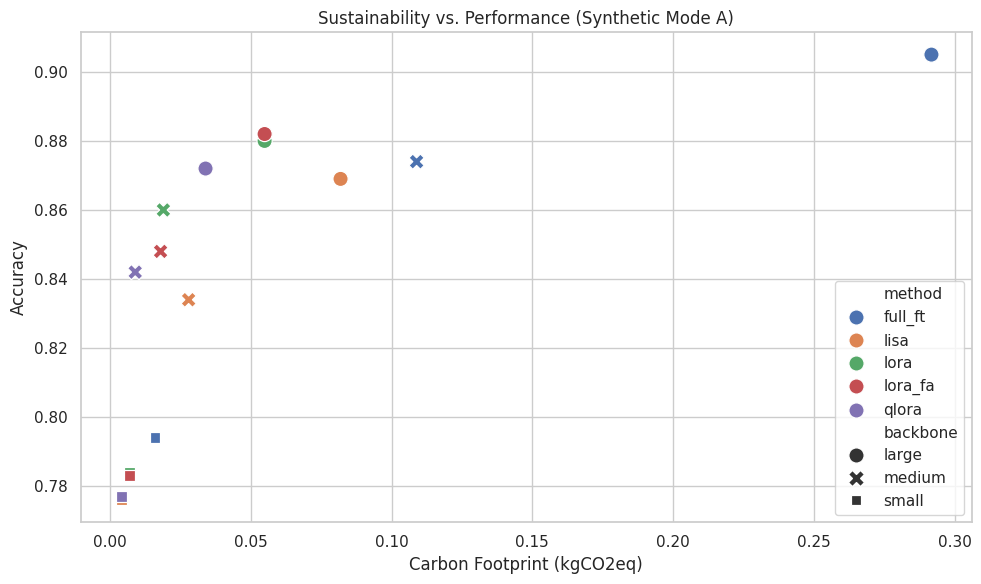

Created export bundle at /content/sustainable_peft_benchmark_bundle.zip


In [ ]:
import shutil
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

summary = pd.read_csv('results/aggregated_scored.csv')

sns.set_theme(style='whitegrid')
fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(
    data=summary,
    x='carbon_kgco2eq_mean',
    y='accuracy_mean',
    hue='method',
    style='backbone',
    s=120,
    ax=ax,
)
ax.set_title('Sustainability vs. Performance (Synthetic Mode A)')
ax.set_xlabel('Carbon Footprint (kgCO2eq)')
ax.set_ylabel('Accuracy')
plt.tight_layout()
Path('results/figures').mkdir(parents=True, exist_ok=True)
plt.savefig('results/figures/pareto_mode_a.png', dpi=160)
plt.show()

staging = Path('export_bundle')
if staging.exists():
    shutil.rmtree(staging)
staging.mkdir(parents=True, exist_ok=True)

for source_path in [
    'results/raw',
    'results/aggregated.csv',
    'results/aggregated_scored.csv',
    'results/pareto_fronts.csv',
    'results/sweep_raw.csv',
    'results/figures',
    'configs/backbones.yaml',
    'configs/tasks.yaml',
    'configs/methods',
]:
    path = Path(source_path)
    destination = staging / path.name
    if path.is_dir():
        shutil.copytree(path, destination, dirs_exist_ok=True)
    elif path.exists():
        shutil.copy2(path, destination)

archive_path = shutil.make_archive('sustainable_peft_benchmark_bundle', 'zip', staging)
print(f'Created export bundle at {archive_path}')

In [ ]:
# @title 🌲 Sustainable PEFT Benchmark Dashboard {display-mode: "form"}

import pandas as pd
import json
from IPython.display import HTML, display
from google.colab import output
import os

# --- Error Reporting ---
def _report_js_error(message):
    print(f"JavaScript Error: {message}")

output.register_callback('report_js_error', _report_js_error)

# --- Data Loading ---
def load_dashboard_data():
    try:
        if not os.path.exists('results/aggregated_gei.csv'):
            return "[]"
        df = pd.read_csv('results/aggregated_gei.csv')
        return df.to_json(orient='records')
    except Exception as e:
        print(f"Error loading data: {e}")
        return "[]"

json_data = load_dashboard_data()

# --- Dashboard HTML/CSS/JS ---
html_template = """
<!DOCTYPE html>
<html lang='en'>
<head>
    <meta charset='UTF-8'>
    <title>Sustainable PEFT Dashboard</title>
    <script src='https://cdn.jsdelivr.net/npm/chart.js'></script>
    <style>
        body { font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif; background-color: #f4f6f8; margin: 0; padding: 20px; color: #333; }
        .dashboard-container { max-width: 1200px; margin: 0 auto; }
        .header { display: flex; justify-content: space-between; align-items: center; margin-bottom: 20px; }
        .kpi-row { display: grid; grid-template-columns: repeat(auto-fit, minmax(240px, 1fr)); gap: 20px; margin-bottom: 20px; }
        .card { background: white; padding: 20px; border-radius: 8px; box-shadow: 0 2px 4px rgba(0,0,0,0.05); text-align: center; }
        .kpi-value { font-size: 24px; font-weight: bold; color: #2c3e50; margin: 10px 0; }
        .kpi-label { font-size: 14px; color: #7f8c8d; text-transform: uppercase; }
        .main-row { display: grid; grid-template-columns: 2fr 1fr; gap: 20px; margin-bottom: 20px; }
        .chart-container { background: white; padding: 20px; border-radius: 8px; box-shadow: 0 2px 4px rgba(0,0,0,0.05); display: flex; flex-direction: column; }
        .canvas-wrapper { position: relative; flex-grow: 1; min-height: 350px; }
        .filters { background: white; padding: 15px; border-radius: 8px; margin-bottom: 20px; display: flex; gap: 20px; align-items: center; box-shadow: 0 2px 4px rgba(0,0,0,0.05); }
        .table-container { background: white; padding: 20px; border-radius: 8px; box-shadow: 0 2px 4px rgba(0,0,0,0.05); overflow-x: auto; }
        table { width: 100%; border-collapse: collapse; margin-top: 10px; }
        th, td { padding: 12px; text-align: left; border-bottom: 1px solid #eee; }
        .method-tag { padding: 4px 8px; border-radius: 4px; font-size: 12px; font-weight: bold; }
        .full_ft { background: #ffebee; color: #c62828; }
        .lora { background: #e3f2fd; color: #1565c0; }
        .qlora { background: #e8f5e9; color: #2e7d32; }
        .lisa { background: #f3e5f5; color: #7b1fa2; }
        .empty-state { text-align: center; padding: 40px; color: #95a5a6; }
    </style>
</head>
<body>
    <div class='dashboard-container'>
        <div class='header'><h2>Sustainable PEFT Benchmark Explorer</h2></div>
        <div id='content-area'>
            <div class='filters'>
                <div><label>Backbone: </label><select id='backboneFilter' onchange='updateDashboard()'><option value='all'>All Sizes</option><option value='small'>Small</option><option value='medium'>Medium</option><option value='large'>Large</option></select></div>
                <div><label>Method: </label><select id='methodFilter' onchange='updateDashboard()'><option value='all'>All Methods</option><option value='full_ft'>Full FT</option><option value='lora'>LoRA</option><option value='qlora'>QLoRA</option><option value='lisa'>LISA</option></select></div>
            </div>
            <div class='kpi-row'>
                <div class='card'><div class='kpi-label'>Best Avg Accuracy</div><div id='kpi-accuracy' class='kpi-value'>-</div></div>
                <div class='card'><div class='kpi-label'>Lowest Carbon (kgCO2)</div><div id='kpi-carbon' class='kpi-value'>-</div></div>
                <div class='card'><div class='kpi-label'>Peak Memory (GB)</div><div id='kpi-mem' class='kpi-value'>-</div></div>
                <div class='card'><div class='kpi-label'>Top Green Index</div><div id='kpi-gei' class='kpi-value'>-</div></div>
            </div>
            <div class='main-row'>
                <div class='chart-container'><h3>Efficiency vs. Performance</h3><div class='canvas-wrapper'><canvas id='scatterChart'></canvas></div></div>
                <div class='chart-container'><h3>GEI Distribution</h3><div class='canvas-wrapper'><canvas id='radarChart'></canvas></div></div>
            </div>
            <div class='table-container'><h3>Benchmark Details</h3><table><thead><tr><th>Method</th><th>Backbone</th><th>Accuracy</th><th>Carbon (kg)</th><th>GEI (Balanced)</th></tr></thead><tbody id='tableBody'></tbody></table></div>
        </div>
        <div id='empty-state' class='empty-state' style='display:none;'><h3>No Data Found</h3><p>Please run the benchmark cells to generate results.</p></div>
    </div>
    <script>
        const rawData = DATA_PLACEHOLDER;
        let scatterChart, radarChart;
        function updateDashboard() {
            if(!rawData || rawData.length === 0) {
                document.getElementById('content-area').style.display = 'none';
                document.getElementById('empty-state').style.display = 'block';
                return;
            }
            const backbone = document.getElementById('backboneFilter').value;
            const method = document.getElementById('methodFilter').value;
            const filtered = rawData.filter(d => (backbone === 'all' || d.backbone === backbone) && (method === 'all' || d.method === method));
            renderKPIs(filtered); renderScatter(filtered); renderRadar(filtered); renderTable(filtered);
        }
        function renderKPIs(data) {
            if (data.length === 0) return;
            document.getElementById('kpi-accuracy').innerText = (Math.max(...data.map(d => d.accuracy_mean)) * 100).toFixed(1) + '%';
            document.getElementById('kpi-carbon').innerText = Math.min(...data.map(d => d.carbon_kgco2eq_mean)).toFixed(3);
            document.getElementById('kpi-mem').innerText = Math.max(...data.map(d => d.peak_mem_gb_mean)).toFixed(1);
            document.getElementById('kpi-gei').innerText = Math.max(...data.map(d => d.gei_balanced)).toFixed(3);
        }
        function renderScatter(data) {
            const ctx = document.getElementById('scatterChart').getContext('2d');
            if (scatterChart) scatterChart.destroy();
            const datasets = [...new Set(data.map(d => d.method))].map(m => ({
                label: m, backgroundColor: {full_ft:'#c62828', lora:'#1565c0', qlora:'#2e7d32', lisa:'#7b1fa2'}[m] || '#999',
                data: data.filter(d => d.method === m).map(d => ({ x: d.carbon_kgco2eq_mean, y: d.accuracy_mean, label: d.backbone }))
            }));
            scatterChart = new Chart(ctx, { type: 'scatter', data: { datasets }, options: { responsive: true, maintainAspectRatio: false } });
        }
        function renderRadar(data) {
            const ctx = document.getElementById('radarChart').getContext('2d');
            if (radarChart) radarChart.destroy();
            const top5 = [...data].sort((a,b) => b.gei_balanced - a.gei_balanced).slice(0, 5);
            radarChart = new Chart(ctx, { type: 'bar', data: { labels: top5.map(d => `${d.method}-${d.backbone}`), datasets: [{ label: 'GEI', data: top5.map(d => d.gei_balanced), backgroundColor: 'rgba(46, 125, 50, 0.7)' }] }, options: { indexAxis: 'y', responsive: true, maintainAspectRatio: false } });
        }
        function renderTable(data) {
            const body = document.getElementById('tableBody'); body.innerHTML = '';
            data.sort((a,b) => b.gei_balanced - a.gei_balanced).forEach(row => {
                const tr = document.createElement('tr');
                tr.innerHTML = `<td><span class='method-tag ${row.method}'>${row.method}</span></td><td>${row.backbone}</td><td>${(row.accuracy_mean * 100).toFixed(1)}%</td><td>${row.carbon_kgco2eq_mean.toFixed(3)}</td><td><strong>${row.gei_balanced.toFixed(3)}</strong></td>`;
                body.appendChild(tr);
            });
        }
        updateDashboard();
    </script>
</body>
</html>
""".replace('DATA_PLACEHOLDER', json_data)

display(HTML(html_template))


Method,Backbone,Accuracy,Carbon (kg),GEI (Balanced)


In [ ]:
# @title 📊 Performance vs. Sustainability Dashboard {display-mode: "form"}

import pandas as pd
import json
from IPython.display import HTML, display
from google.colab import output
import os

def _report_js_error(message):
    print(f"JavaScript Error: {message}")

output.register_callback('report_js_error', _report_js_error)

def load_data():
    path = 'results/aggregated_gei.csv'
    if os.path.exists(path):
        return pd.read_csv(path).to_json(orient='records')
    return "[]"

json_data = load_data()

html_template = """
<!DOCTYPE html>
<html>
<head>
    <script src="https://cdn.jsdelivr.net/npm/chart.js"></script>
    <style>
        body { font-family: sans-serif; background-color: #f4f6f8; padding: 20px; color: #333; }
        .container { max-width: 1200px; margin: 0 auto; }
        .header { margin-bottom: 20px; }
        .filters { background: white; padding: 15px; border-radius: 8px; margin-bottom: 20px; box-shadow: 0 2px 4px rgba(0,0,0,0.05); display: flex; gap: 20px; }
        .kpi-row { display: grid; grid-template-columns: repeat(4, 1fr); gap: 20px; margin-bottom: 20px; }
        .card { background: white; padding: 20px; border-radius: 8px; box-shadow: 0 2px 4px rgba(0,0,0,0.05); text-align: center; }
        .kpi-val { font-size: 22px; font-weight: bold; color: #2c3e50; }
        .kpi-lab { font-size: 12px; color: #7f8c8d; text-transform: uppercase; margin-top: 5px; }
        .main-row { display: grid; grid-template-columns: 2fr 1fr; gap: 20px; margin-bottom: 20px; }
        .chart-box { background: white; padding: 20px; border-radius: 8px; box-shadow: 0 2px 4px rgba(0,0,0,0.05); display: flex; flex-direction: column; }
        .canvas-wrapper { position: relative; flex-grow: 1; min-height: 350px; }
        .table-box { background: white; padding: 20px; border-radius: 8px; box-shadow: 0 2px 4px rgba(0,0,0,0.05); overflow-x: auto; }
        table { width: 100%; border-collapse: collapse; }
        th, td { padding: 12px; text-align: left; border-bottom: 1px solid #eee; }
        th { background: #f8f9fa; font-size: 13px; }
    </style>
</head>
<body>
    <div class="container">
        <div class="header"><h2>PEFT Sustainability Analytics</h2></div>
        <div class="filters">
            <select id="backboneSel" onchange="render()">
                <option value="all">All Backbones</option>
                <option value="small">Small</option>
                <option value="medium">Medium</option>
                <option value="large">Large</option>
            </select>
            <select id="methodSel" onchange="render()">
                <option value="all">All Methods</option>
                <option value="full_ft">Full FT</option>
                <option value="lora">LoRA</option>
                <option value="qlora">QLoRA</option>
                <option value="lisa">LISA</option>
            </select>
        </div>
        <div class="kpi-row">
            <div class="card"><div id="kpi-acc" class="kpi-val">-</div><div class="kpi-lab">Max Accuracy</div></div>
            <div class="card"><div id="kpi-carb" class="kpi-val">-</div><div class="kpi-lab">Min Carbon (kg)</div></div>
            <div class="card"><div id="kpi-gei" class="kpi-val">-</div><div class="kpi-lab">Avg Green Index</div></div>
            <div class="card"><div id="kpi-mem" class="kpi-val">-</div><div class="kpi-lab">Avg Peak Memory (GB)</div></div>
        </div>
        <div class="main-row">
            <div class="chart-box">
                <h3>Accuracy vs. Carbon Footprint</h3>
                <div class="canvas-wrapper"><canvas id="scatter"></canvas></div>
            </div>
            <div class="chart-box">
                <h3>Carbon per Method</h3>
                <div class="canvas-wrapper"><canvas id="bar"></canvas></div>
            </div>
        </div>
        <div class="table-box">
            <h3>Method Comparison</h3>
            <table>
                <thead><tr><th>Method</th><th>Backbone</th><th>Accuracy</th><th>Carbon (kg)</th><th>GEI</th></tr></thead>
                <tbody id="tBody"></tbody>
            </table>
        </div>
    </div>
    <script>
        window.onerror = (m) => google.colab.kernel.invokeFunction('report_js_error', [m], {});
        const raw = DATA_PLACEHOLDER;
        let sChart, bChart;
        function render() {
            const b = document.getElementById('backboneSel').value;
            const m = document.getElementById('methodSel').value;
            const data = raw.filter(d => (b==='all'||d.backbone===b) && (m==='all'||d.method===m));

            document.getElementById('kpi-acc').innerText = data.length ? (Math.max(...data.map(d=>d.accuracy_mean))*100).toFixed(1)+'%' : '-';
            document.getElementById('kpi-carb').innerText = data.length ? Math.min(...data.map(d=>d.carbon_kgco2eq_mean)).toFixed(3) : '-';
            document.getElementById('kpi-gei').innerText = data.length ? (data.reduce((a,c)=>a+c.gei_balanced,0)/data.length).toFixed(3) : '-';
            document.getElementById('kpi-mem').innerText = data.length ? (data.reduce((a,c)=>a+c.peak_mem_gb_mean,0)/data.length).toFixed(1) : '-';

            if(sChart) sChart.destroy();
            sChart = new Chart(document.getElementById('scatter'), {
                type: 'scatter', data: { datasets: [{ label: 'PEFT Runs', data: data.map(d=>({x: d.carbon_kgco2eq_mean, y: d.accuracy_mean, label: d.method+'/'+d.backbone})), backgroundColor: '#3498db' }] },
                options: { responsive: true, maintainAspectRatio: false, scales: { x: { title: { display:true, text:'Carbon (kgCO2eq)' }}, y: { title: { display:true, text:'Accuracy' }} } }
            });

            if(bChart) bChart.destroy();
            const meths = [...new Set(data.map(d=>d.method))];
            bChart = new Chart(document.getElementById('bar'), {
                type: 'bar', data: { labels: meths, datasets: [{ label: 'Avg Carbon', data: meths.map(me => data.filter(d=>d.method===me).reduce((a,c)=>a+c.carbon_kgco2eq_mean,0)/data.filter(d=>d.method===me).length), backgroundColor: '#2ecc71' }] },
                options: { responsive: true, maintainAspectRatio: false }
            });

            const body = document.getElementById('tBody'); body.innerHTML = '';
            data.sort((x,y) => y.accuracy_mean - x.accuracy_mean).forEach(r => {
                const tr = document.createElement('tr');
                tr.innerHTML = `<td>${r.method}</td><td>${r.backbone}</td><td>${(r.accuracy_mean*100).toFixed(1)}%</td><td>${r.carbon_kgco2eq_mean.toFixed(4)}</td><td>${r.gei_balanced.toFixed(3)}</td>`;
                body.appendChild(tr);
            });
        }
        render();
    </script>
</body>
</html>
""".replace('DATA_PLACEHOLDER', json_data)

display(HTML(html_template))

Method,Backbone,Accuracy,Carbon (kg),GEI
